In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250718-naturalness-training-tuning',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'SHOC2_HUMAN_Kwon_2022', 'CBS_HUMAN_Sun_2020', 'OXDA_RHOTO_Vanella_2023_activity', 'PPM1D_HUMAN_Miller_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'HSP82_YEAST_Flynn_2019', 'BLAT_ECOLX_Firnberg_2014', 'HEM3_HUMAN_Loggerenberg_2023', 'ANCSZ_Hobbs_2022'}


In [4]:
round_metrics_df.config_name.unique()

array(['FolDE-hotstart-20epochs', 'FolDE-hotstart-100epochs',
       'FolDE-hotstart-10epochs', 'FolDE-hotstart-1epochs',
       'FolDE-hotstart-200epochs', 'FolDE-hotstart-0epochs',
       'FolDE-hotstart-5epochs', 'FolDE-hotstart-50epochs'], dtype=object)

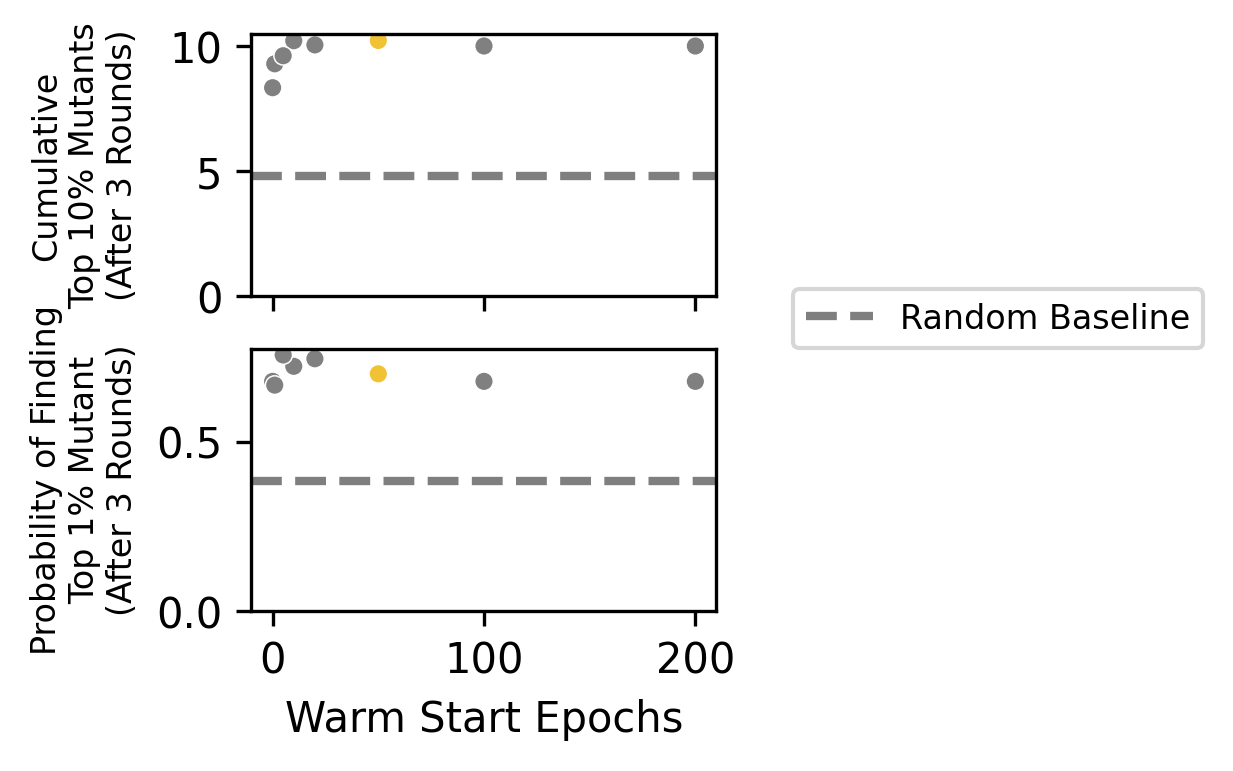

In [23]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from notebooks.jacob.paperplots.util import get_random_baseline_number_of_top_performers, get_random_baseline_probability_of_top_performer

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2, 2.5), sharex=True, dpi=300)

PLOT_TYPE = 'scatter'
ROUND = 3
ROUND_SIZE = 16  # Number of mutants per round
# PLOT_TYPE = 'bar'
# PLOT_TYPE = 'boxplot'

config_name_list = [
    # ('FolDE-base', 'base'),
    ('FolDE-hotstart-0epochs', '0 Rounds'),
    ('FolDE-hotstart-1epochs', '1 Rounds'),
    ('FolDE-hotstart-5epochs', '5 Rounds'),
    ('FolDE-hotstart-10epochs', '10 Rounds'),
    ('FolDE-hotstart-20epochs', '20 Rounds'),
    ('FolDE-hotstart-50epochs', '50 Rounds'),
    ('FolDE-hotstart-100epochs', '100 Rounds'),
    ('FolDE-hotstart-200epochs', '200 Rounds'),
]

config_name_map = {k: v for k, v in config_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == ROUND].copy()
initial_metrics_df = initial_metrics_df[initial_metrics_df.config_name.isin([c[0] for c in config_name_list])]

initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: config_name_map[x])
initial_metrics_df['Warm Start Epochs'] = initial_metrics_df.model_name.apply(lambda x: int(x.split(' ')[0]))


for ii, (ax, metric) in enumerate(zip(
        [ax1, ax2],
        ['cumulative_10pct_hits', 'has_found_top_1pct']
    )):
    grouped_df = initial_metrics_df.groupby(['model_name', 'round_num', 'Warm Start Epochs'])[metric].mean().reset_index()
    def get_color(model_name):
        if model_name == '50 Rounds':
            return '#F1C233'
        else:
            return 'grey'
    if PLOT_TYPE == 'scatter':
        sns.scatterplot(
            data=grouped_df,
            hue='model_name',
            x='Warm Start Epochs',
            y=metric,
            ax=ax,
            s=20,
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            legend=False,
            # label=lambda x: '50 Rounds' if get_color(x) == '#F1C233' else None
            # saturation=1.0
        )
    elif PLOT_TYPE == 'bar':
        sns.barplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in config_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            ax=ax,
            saturation=1.0
        )
    elif PLOT_TYPE == 'boxplot':
        sns.boxplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in config_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            ax=ax,
            # saturation=1.0
        )
    else:
        assert False, PLOT_TYPE
    # ax.set_xticklabels([int(c[1].split(' ')[0]) for c in config_name_list], rotation=45, ha='right')

    # Calculate random baseline
    if metric == 'cumulative_10pct_hits':
        baseline = get_random_baseline_number_of_top_performers(ROUND_SIZE, ROUND, 0.10)
    elif metric == 'has_found_top_1pct':
        baseline = get_random_baseline_probability_of_top_performer(ROUND_SIZE, ROUND, 0.01)
    else:
        baseline = 0.01 if metric == 'held_out_1pct_recall' else 0.1
    
    ax.axhline(
        y=baseline,
        color='black',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='Random Baseline'
    )

    if metric == 'held_out_1pct_recall':
        ax.set_ylabel('Recall@1%', fontsize=8, rotation=0, ha='right')
    elif metric == 'held_out_10pct_recall':
        ax.set_ylabel('Recall@10%', fontsize=8, rotation=0, ha='right')
    elif metric == 'cumulative_10pct_hits':
        ax.set_ylabel('Cumulative\nTop 10% Mutants\n(After 3 Rounds)', fontsize=8)
    elif metric == 'has_found_top_1pct':
        ax.set_ylabel('Probability of Finding\nTop 1% Mutant\n(After 3 Rounds)', fontsize=8)
    else:
        raise ValueError(f"Unknown metric: {metric}")

    ax.set_ylim(0, ax.get_ylim()[1])

if PLOT_TYPE == 'scatter':
    ax2.set_xlabel('Warm Start Epochs')
else:
    ax2.set_xlabel('Warm Start Epochs')

fig.align_ylabels([ax1, ax2])
# Add legend to the right side of the figure
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=True)


# ax1.set_title(f'Warm Start Effect on Round {ROUND} Recall')